# Superstore Sales & Profitability Analysis Using SQL and Tableau

## 1. Introduction

This case study analyzes Superstore sales data to identify the main drivers of revenue and profit. The goal is to understand which regions, product categories, customer segments, and discount levels are helping or hurting business performance.

The project uses Python for data preparation and visualization, SQL for analysis, and Tableau for the final interactive dashboard.

## 2. Business Task

The business wants to better understand where it is generating strong profit and where profitability is weak. Sales alone do not show the full picture because some high-sales products, regions, or customer groups may have low or negative profit.

This analysis will answer the following questions:

1. Which regions generate the most sales and profit?
2. Which product categories and sub-categories are most and least profitable?
3. Which customer segments contribute the most revenue and profit?
4. How do discounts affect profit margin?
5. What recommendations can improve profitability?

## 3. Data Source

The dataset used for this project is the Sample Superstore dataset from Kaggle. It contains retail sales records from 2014 to 2017 and includes order details, customer information, geographic fields, product categories, sales, quantity, discounts, and profit.

This dataset is appropriate for the analysis because it includes the fields needed to evaluate business performance by region, product category, customer segment, and discount level.

## 4. Tools Used

- Python: data loading, data cleaning, calculated fields, and visualizations
- SQL: business analysis queries using SQLite
- Tableau: final interactive dashboard
- Kaggle Notebook: project documentation and case study presentation

## 5. Data Loading

First, I imported the required Python libraries, located the CSV file attached to the Kaggle notebook, and loaded the dataset into a pandas dataframe.

In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Find CSV files attached to the Kaggle notebook
csv_files = []

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_files.append(os.path.join(dirname, filename))

csv_files

['/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv']

In [3]:
# Load the Superstore dataset
file_path = csv_files[0]

df = pd.read_csv(file_path, encoding="cp1252")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## 6. Initial Dataset Inspection

I reviewed the dataset structure to confirm the number of rows and columns, check data types, identify missing values, and check for duplicate rows.

In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 7. Data Cleaning and Processing

The dataset contained 9,994 rows and 21 columns. The initial inspection showed that there were no missing values and no duplicate rows.

The date columns were originally stored as text, so I converted them into datetime format. I also cleaned the column names by converting them to lowercase and replacing spaces and hyphens with underscores. This makes the data easier to use with SQL.

I created additional fields for analysis, including profit margin, shipping days, order month, and discount band.

In [8]:
# Clean column names for SQL readability
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [9]:
# Convert date columns from text to datetime
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

df[["order_date", "ship_date"]].head()

,order_date,ship_date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [10]:
# Create calculated fields for analysis
df["profit_margin"] = df["profit"] / df["sales"]
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)

def discount_band(discount):
    if discount == 0:
        return "No Discount"
    elif discount <= 0.2:
        return "Low Discount"
    elif discount <= 0.5:
        return "Medium Discount"
    else:
        return "High Discount"

df["discount_band"] = df["discount"].apply(discount_band)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,profit_margin,shipping_days,order_month,discount_band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,0.16,3,2016-11,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,0.30,3,2016-11,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,0.47,4,2016-06,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,-0.40,7,2015-10,Medium Discount
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,0.11,7,2015-10,Low Discount


In [11]:
# Confirm the new columns were added
df[["sales", "profit", "profit_margin", "shipping_days", "order_month", "discount", "discount_band"]].head()

,sales,profit,profit_margin,shipping_days,order_month,discount,discount_band
0,261.96,41.91,0.16,3,2016-11,0.00,No Discount
1,731.94,219.58,0.30,3,2016-11,0.00,No Discount
2,14.62,6.87,0.47,4,2016-06,0.00,No Discount
3,957.58,-383.03,-0.40,7,2015-10,0.45,Medium Discount
4,22.37,2.52,0.11,7,2015-10,0.20,Low Discount


In [12]:
# Check the date range of the dataset
date_range = pd.DataFrame({
    "first_order_date": [df["order_date"].min()],
    "last_order_date": [df["order_date"].max()]
})

date_range

,first_order_date,last_order_date
0,2014-01-03,2017-12-30


In [13]:
# Check number of unique orders and customers
summary_counts = pd.DataFrame({
    "total_rows": [len(df)],
    "unique_orders": [df["order_id"].nunique()],
    "unique_customers": [df["customer_id"].nunique()],
    "unique_products": [df["product_id"].nunique()]
})

summary_counts

,total_rows,unique_orders,unique_customers,unique_products
0,9994,5009,793,1862


## 8. SQL Setup

To complete the analysis with SQL, I loaded the cleaned dataframe into an in-memory SQLite database. This allowed SQL queries to be used directly inside the Kaggle notebook.

In [14]:
# Create SQLite database in memory
conn = sqlite3.connect(":memory:")

# SQLite works best with dates stored as text
df_sql = df.copy()
df_sql["order_date"] = df_sql["order_date"].dt.strftime("%Y-%m-%d")
df_sql["ship_date"] = df_sql["ship_date"].dt.strftime("%Y-%m-%d")

# Load the DataFrame into SQL
df_sql.to_sql("superstore", conn, index=False, if_exists="replace")

9994

In [15]:
# Helper function to run SQL queries
def run_query (query):
    return pd.read_sql_query(query, conn)

In [16]:
# Test the SQL table
run_query("""
SELECT *
FROM superstore
LIMIT 5;
""")

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,profit_margin,shipping_days,order_month,discount_band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,0.16,3,2016-11,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,0.30,3,2016-11,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,0.47,4,2016-06,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,-0.40,7,2015-10,Medium Discount
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,0.11,7,2015-10,Low Discount


## 9. SQL Data Validation

After loading the cleaned data into SQL, I validated the table by checking row count, unique orders, unique customers, unique products, and overall sales and profit totals.

In [17]:
run_query("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders,
    COUNT(DISTINCT customer_id) AS unique_customers,
    COUNT(DISTINCT product_id) AS unique_products
FROM superstore;
""")

,total_rows,unique_orders,unique_customers,unique_products
0,9994,5009,793,1862


In [18]:
run_query("""
SELECT
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent
FROM superstore;
""")

,total_sales,total_profit,profit_margin_percent
0,"2,297,200.86","286,397.02",12.47


## 10. Analysis

The analysis uses SQL queries and visualizations to evaluate business performance across sales, profit, margin, geography, products, customers, discounts, time, shipping, and individual products.

### 10.1 Overall Business Performance

The first step in the analysis was to calculate total sales, total profit, profit margin, total orders, total customers, and average discount. These metrics provide a high-level view of how the business performed during the full date range.

In [19]:
overall_performance = run_query("""
SELECT
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS total_customers,
    ROUND(AVG(discount) * 100, 2) AS avg_discount_percent
FROM superstore;
""")

overall_performance

,total_sales,total_profit,profit_margin_percent,total_orders,total_customers,avg_discount_percent
0,"2,297,200.86","286,397.02",12.47,5009,793,15.62


The dataset contains approximately $2.30M in total sales and $286.4K in total profit. The overall profit margin is 12.47%, which shows that the business is profitable overall. However, this high-level result does not explain which regions, products, customer segments, or discount levels are driving or reducing profitability.

### 10.2 Regional Performance

Next, I analyzed sales and profit by region. This helps identify which geographic areas are contributing the most to overall business performance.

In [20]:
region_performance = run_query("""
SELECT
    region,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY region
ORDER BY total_profit DESC;
""")

region_performance

,region,total_sales,total_profit,profit_margin_percent,total_orders
0,West,"725,457.82","108,418.45",14.94,1611
1,East,"678,781.24","91,522.78",13.48,1401
2,South,"391,721.91","46,749.43",11.93,822
3,Central,"501,239.89","39,706.36",7.92,1175


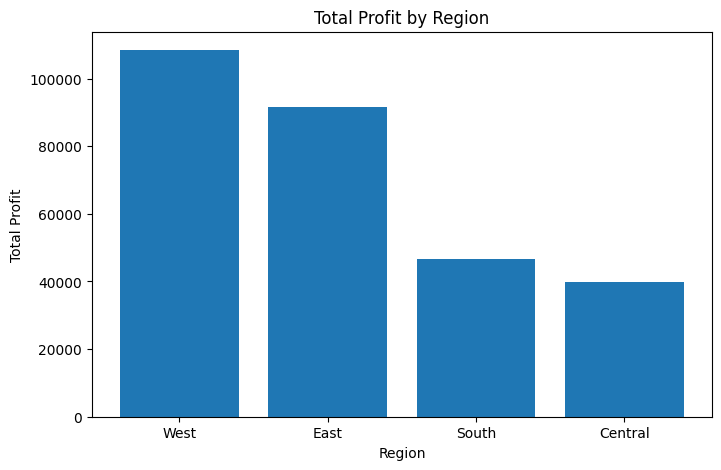

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(region_performance["region"], region_performance["total_profit"])
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

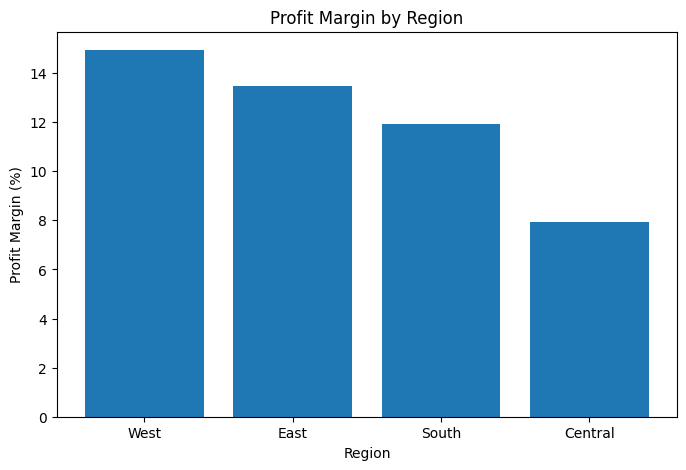

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(region_performance["region"], region_performance["profit_margin_percent"])
plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

The West region generated the highest total profit, followed by the East region. The Central region had the weakest total profit and the lowest profit margin among the regions. This suggests that the business should review regional differences to understand why some areas are more profitable than others.

### 10.3 State-Level Performance

After reviewing regions, I analyzed performance by state. This provides a more detailed view of geographic performance and helps identify specific states that are driving profit or losses.

In [23]:
state_performance = run_query("""
SELECT
    state,
    region,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY state, region
ORDER BY total_profit DESC;
""")

state_performance.head(10)

,state,region,total_sales,total_profit,profit_margin_percent,total_orders
0,California,West,"457,687.63","76,381.39",16.69,1021
1,New York,East,"310,876.27","74,038.55",23.82,562
2,Washington,West,"138,641.27","33,402.65",24.09,256
3,Michigan,Central,"76,269.61","24,463.19",32.07,117
4,Virginia,South,"70,636.72","18,597.95",26.33,115
5,Indiana,Central,"53,555.36","18,382.94",34.33,73
6,Georgia,South,"49,095.84","16,250.04",33.10,91
7,Kentucky,South,"36,591.75","11,199.70",30.61,61
8,Minnesota,Central,"29,863.15","10,823.19",36.24,44
9,Delaware,East,"27,451.07","9,977.37",36.35,44


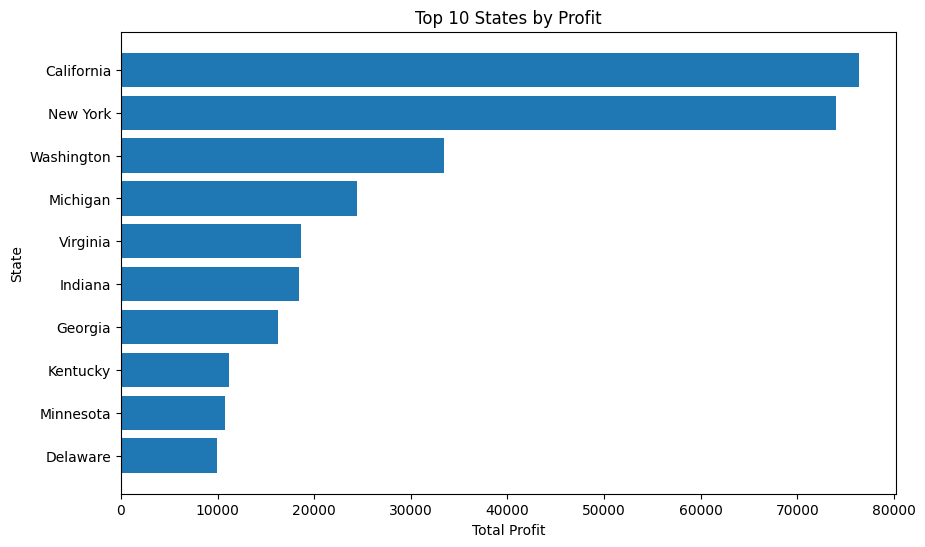

In [24]:
top_10_states = state_performance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_states["state"], top_10_states["total_profit"])
plt.title("Top 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()

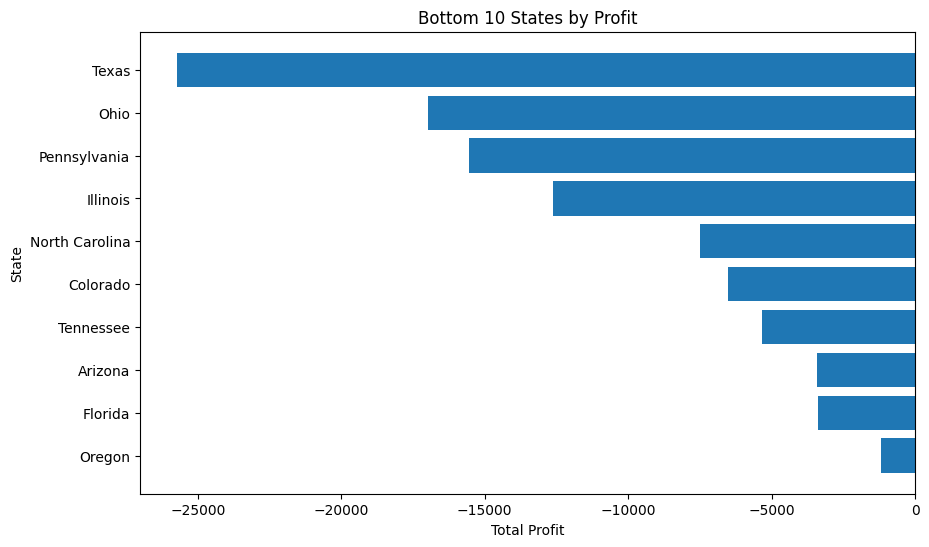

In [25]:
bottom_10_states = state_performance.tail(10).sort_values("total_profit")

plt.figure(figsize=(10, 6))
plt.barh(bottom_10_states["state"], bottom_10_states["total_profit"])
plt.title("Bottom 10 States by Profit")
plt.xlabel("Total Profit")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()

State-level results show that profitability varies widely within regions. Some states generate strong profit, while others produce losses. This supports the need to look beyond total sales and evaluate profit by location before making regional business decisions.

### 10.4 Product Category Performance

After analyzing geography, I reviewed sales and profit by product category. This helps determine whether the main product categories are generating strong profit or only high sales volume.

In [26]:
category_performance = run_query("""
SELECT
    category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY category
ORDER BY total_profit DESC;
""")

category_performance

,category,total_sales,total_profit,profit_margin_percent,total_orders
0,Technology,"836,154.03","145,454.95",17.40,1544
1,Office Supplies,"719,047.03","122,490.80",17.04,3742
2,Furniture,"741,999.80","18,451.27",2.49,1764


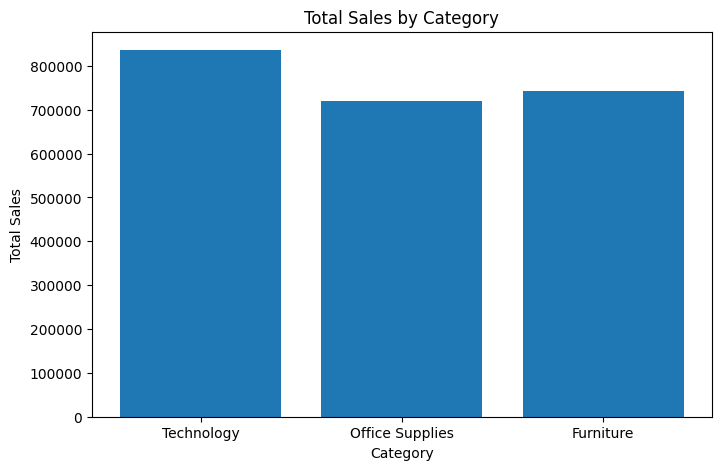

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(category_performance["category"], category_performance["total_sales"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

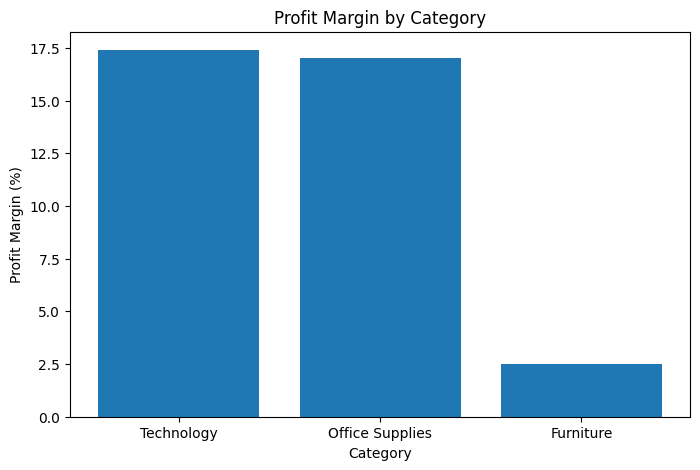

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(category_performance["category"], category_performance["profit_margin_percent"])
plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

Technology generated the highest total profit, followed by Office Supplies. Furniture generated a large amount of sales but had much weaker profitability than the other categories. This shows that sales volume alone does not always mean a category is performing well.

### 10.5 Sub-Category Performance

To understand the category results in more detail, I analyzed sales and profit by sub-category. This helps identify specific product groups that are driving profit or creating losses.

In [29]:
subcategory_performance = run_query("""
SELECT
    sub_category,
    category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY sub_category, category
ORDER BY total_profit DESC;
""")

subcategory_performance

,sub_category,category,total_sales,total_profit,profit_margin_percent,total_orders
0,Copiers,Technology,"149,528.03","55,617.82",37.20,68
1,Phones,Technology,"330,007.05","44,515.73",13.49,814
2,Accessories,Technology,"167,380.32","41,936.64",25.05,718
3,Paper,Office Supplies,"78,479.21","34,053.57",43.39,1191
4,Binders,Office Supplies,"203,412.73","30,221.76",14.86,1316
5,Chairs,Furniture,"328,449.10","26,590.17",8.10,576
6,Storage,Office Supplies,"223,843.61","21,278.83",9.51,777
7,Appliances,Office Supplies,"107,532.16","18,138.01",16.87,451
8,Furnishings,Furniture,"91,705.16","13,059.14",14.24,877
9,Envelopes,Office Supplies,"16,476.40","6,964.18",42.27,249


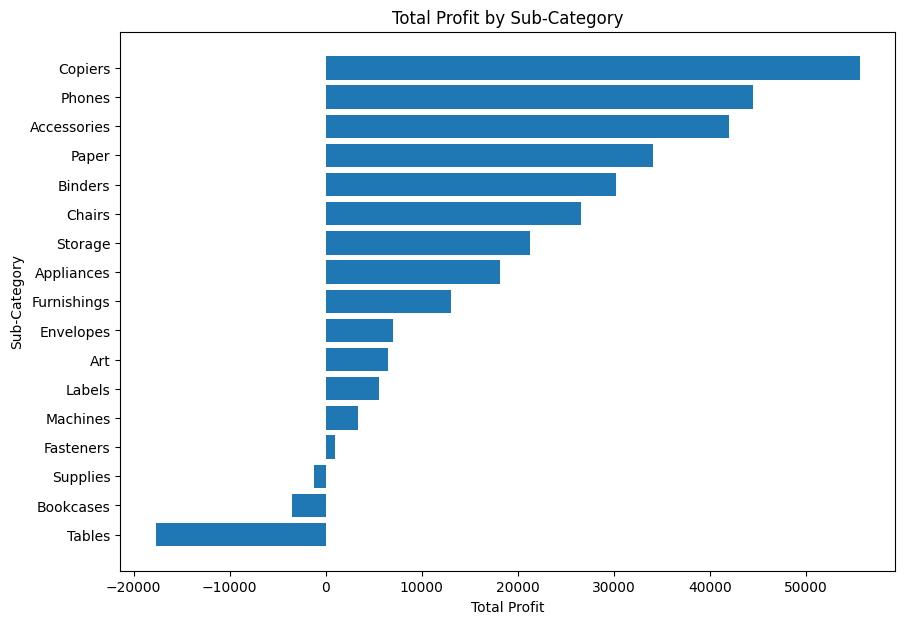

In [30]:
plt.figure(figsize=(10, 7))
plt.barh(subcategory_performance["sub_category"], subcategory_performance["total_profit"])
plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.gca().invert_yaxis()
plt.show()

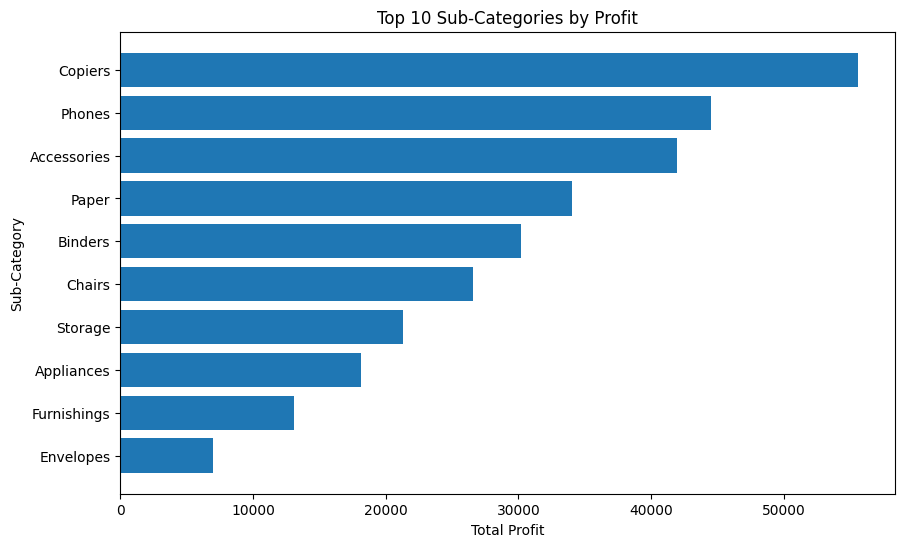

In [31]:
top_10_subcategories = subcategory_performance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_subcategories["sub_category"], top_10_subcategories["total_profit"])
plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.gca().invert_yaxis()
plt.show()

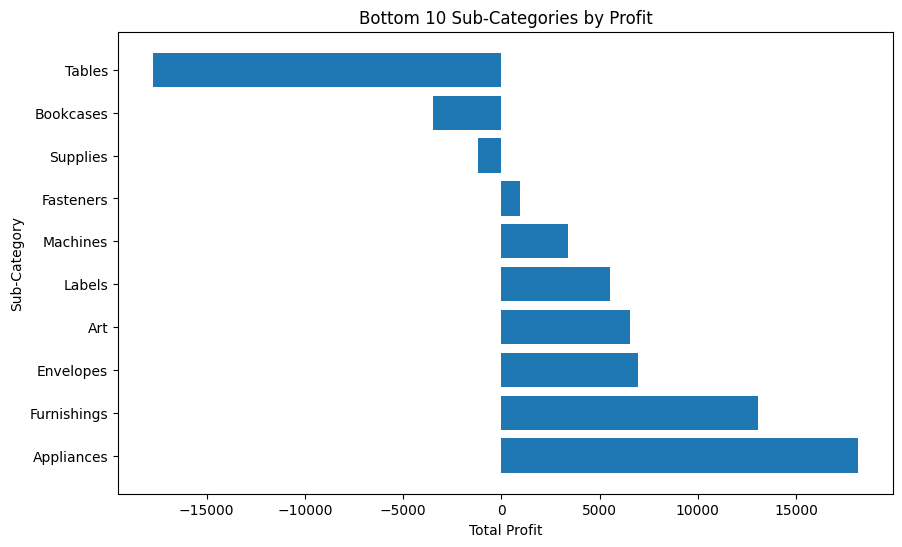

In [32]:
bottom_10_subcategories = subcategory_performance.tail(10).sort_values("total_profit")

plt.figure(figsize=(10, 6))
plt.barh(bottom_10_subcategories["sub_category"], bottom_10_subcategories["total_profit"])
plt.title("Bottom 10 Sub-Categories by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.gca().invert_yaxis()
plt.show()

In [33]:
subcategory_margin = run_query("""
SELECT
    sub_category,
    category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent
FROM superstore
GROUP BY sub_category, category
ORDER BY profit_margin_percent ASC;
""")

subcategory_margin

,sub_category,category,total_sales,total_profit,profit_margin_percent
0,Tables,Furniture,"206,965.53","-17,725.48",-8.56
1,Bookcases,Furniture,"114,880.00","-3,472.56",-3.02
2,Supplies,Office Supplies,"46,673.54","-1,189.10",-2.55
3,Machines,Technology,"189,238.63","3,384.76",1.79
4,Chairs,Furniture,"328,449.10","26,590.17",8.10
5,Storage,Office Supplies,"223,843.61","21,278.83",9.51
6,Phones,Technology,"330,007.05","44,515.73",13.49
7,Furnishings,Furniture,"91,705.16","13,059.14",14.24
8,Binders,Office Supplies,"203,412.73","30,221.76",14.86
9,Appliances,Office Supplies,"107,532.16","18,138.01",16.87


Sub-category performance shows that some product groups are much more profitable than others. The strongest sub-categories should be prioritized because they generate high profit, while the weakest sub-categories should be reviewed for pricing, discounting, product cost, or demand issues.

This analysis is especially important because a category can look strong at a high level while still containing individual sub-categories that lose money.

### 10.6 Customer Segment Performance

Next, I analyzed sales and profit by customer segment. This helps determine which customer groups contribute the most revenue and profit to the business.

In [34]:
segment_performance = run_query("""
SELECT
    segment,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT customer_id) AS unique_customers
FROM superstore
GROUP BY segment
ORDER BY total_profit DESC;
""")

segment_performance

,segment,total_sales,total_profit,profit_margin_percent,total_orders,unique_customers
0,Consumer,"1,161,401.34","134,119.21",11.55,2586,409
1,Corporate,"706,146.37","91,979.13",13.03,1514,236
2,Home Office,"429,653.15","60,298.68",14.03,909,148


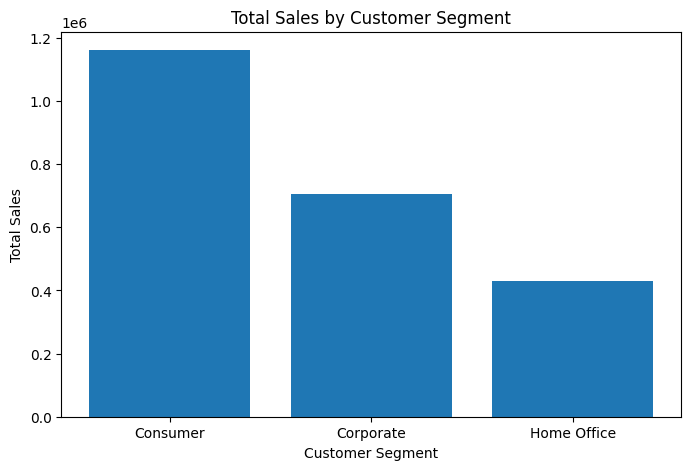

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(segment_performance["segment"], segment_performance["total_sales"])
plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

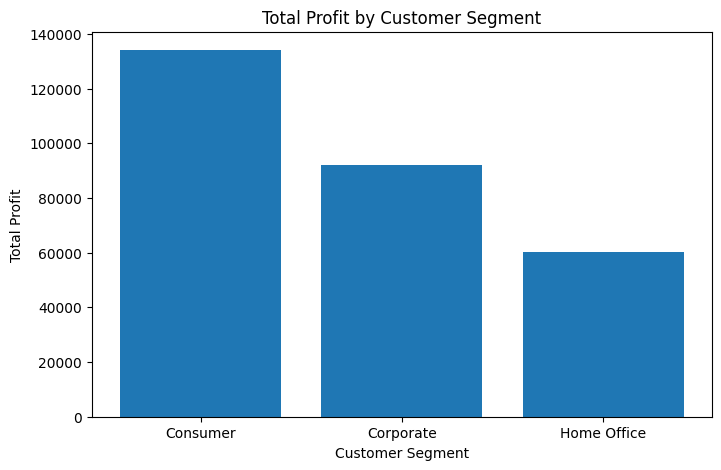

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(segment_performance["segment"], segment_performance["total_profit"])
plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

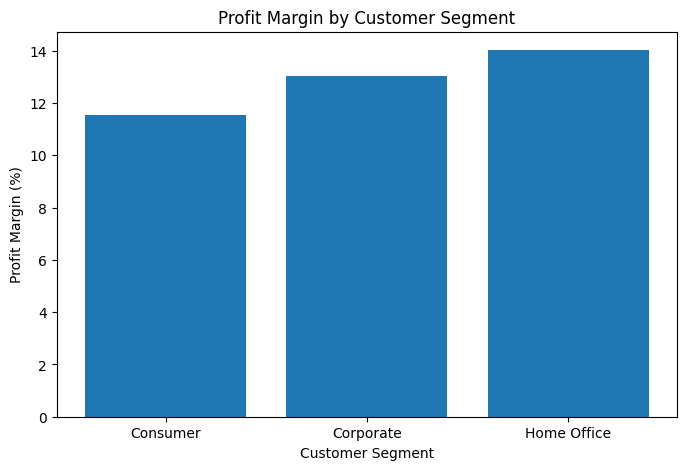

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(segment_performance["segment"], segment_performance["profit_margin_percent"])
plt.title("Profit Margin by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

The Consumer segment generated the highest total sales and total profit. Corporate was the second strongest segment, followed by Home Office.

Although Consumer contributed the most total profit, the segment results should also be compared by profit margin. This helps determine whether the largest customer group is also the most efficient from a profitability perspective.

### 10.7 Discount Impact

Discounting was analyzed to understand whether higher discounts are associated with weaker profitability. This is important because discounts may increase sales volume while reducing or eliminating profit.

In [38]:
discount_performance = run_query("""
SELECT
    discount_band,
    COUNT(*) AS order_lines,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent
FROM superstore
GROUP BY discount_band
ORDER BY profit_margin_percent DESC;
""")

discount_performance

,discount_band,order_lines,total_sales,total_profit,profit_margin_percent
0,No Discount,4798,"1,087,908.47","320,987.60",29.51
1,Low Discount,3803,"846,522.24","100,785.47",11.91
2,Medium Discount,537,"298,541.41","-58,817.00",-19.70
3,High Discount,856,"64,228.74","-76,559.05",-119.20


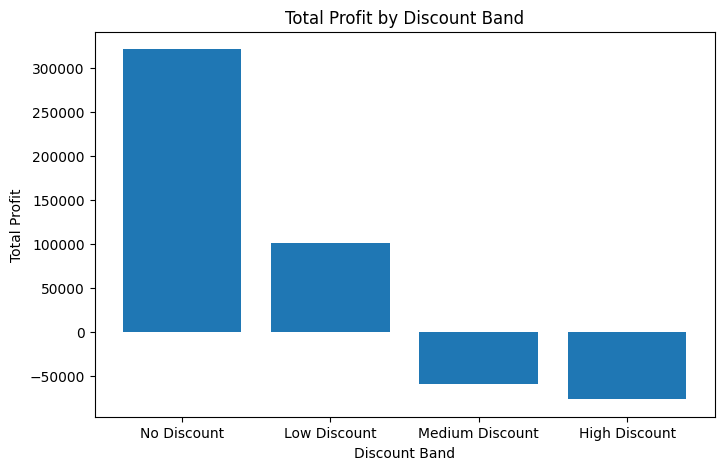

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(discount_performance["discount_band"], discount_performance["total_profit"])
plt.title("Total Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.show()

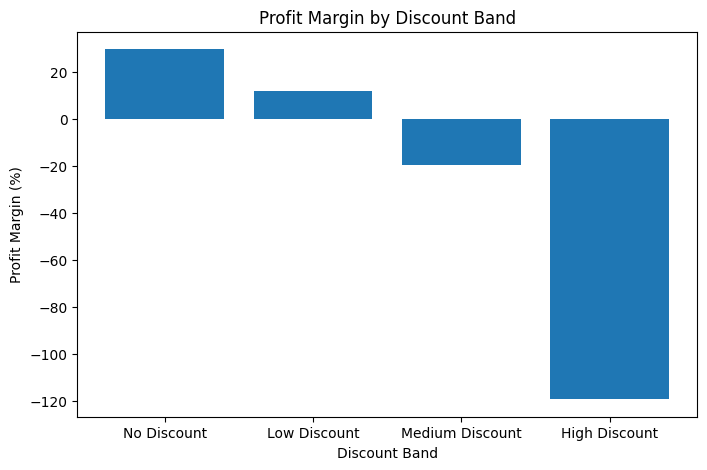

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(discount_performance["discount_band"], discount_performance["profit_margin_percent"])
plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

In [41]:
discount_detail = run_query("""
SELECT
    discount,
    COUNT(*) AS order_lines,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent
FROM superstore
GROUP BY discount
ORDER BY discount;
""")

discount_detail

,discount,order_lines,total_sales,total_profit,profit_margin_percent
0,0.00,4798,"1,087,908.47","320,987.60",29.51
1,0.10,94,"54,369.35","9,029.18",16.61
2,0.15,52,"27,558.52","1,418.99",5.15
3,0.20,3657,"764,594.37","90,337.31",11.82
4,0.30,227,"103,226.65","-10,369.28",-10.05
5,0.32,27,"14,493.46","-2,391.14",-16.50
6,0.40,206,"116,417.78","-23,057.05",-19.81
7,0.45,11,"5,484.97","-2,493.11",-45.45
8,0.50,66,"58,918.54","-20,506.43",-34.80
9,0.60,138,"6,644.70","-5,944.66",-89.46


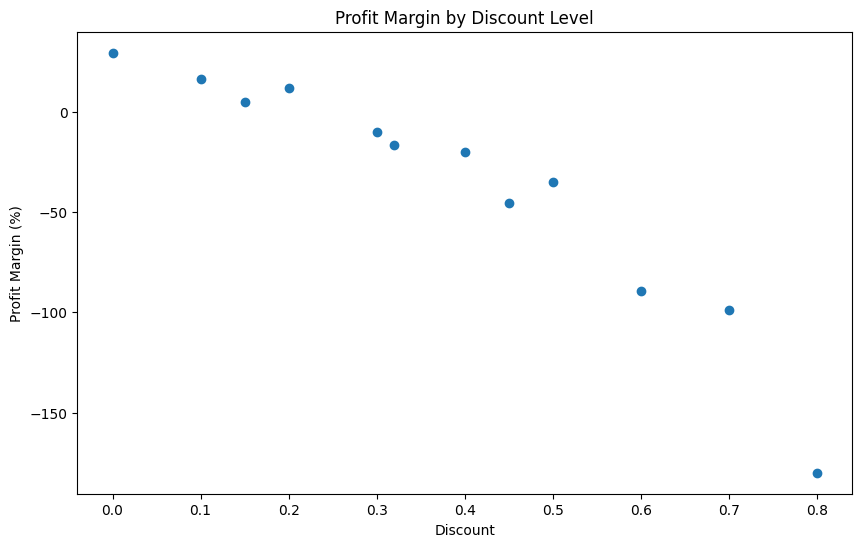

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(discount_detail["discount"], discount_detail["profit_margin_percent"])
plt.title("Profit Margin by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.show()

Discounting had a major impact on profitability. Orders with no discount or low discounts were profitable overall, while higher discount bands produced weaker or negative profit margins.

This suggests that aggressive discounting may be hurting the business. The company should review when and where discounts above 20% are being used, especially for low-margin products and underperforming categories.

### 10.8 Discount Impact by Category

Because Furniture had weak profitability, I also analyzed discounting by category. This helps determine whether certain categories are more affected by discounting than others.

In [43]:
category_discount_performance = run_query("""
SELECT
    category,
    discount_band,
    COUNT(*) AS order_lines,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent
FROM superstore
GROUP BY category, discount_band
ORDER BY category, profit_margin_percent DESC;
""")

category_discount_performance

,category,discount_band,order_lines,total_sales,total_profit,profit_margin_percent
0,Furniture,No Discount,836,"256,025.27","58,133.08",22.71
1,Furniture,Low Discount,743,"290,823.78","14,795.95",5.09
2,Furniture,Medium Discount,389,"186,046.66","-44,638.16",-23.99
3,Furniture,High Discount,153,"9,104.08","-9,839.59",-108.08
4,Office Supplies,No Discount,3129,"442,150.00","130,506.11",29.52
5,Office Supplies,Low Discount,2217,"237,373.89","39,124.83",16.48
6,Office Supplies,High Discount,680,"39,523.15","-47,140.14",-119.27
7,Technology,No Discount,833,"389,733.20","132,348.42",33.96
8,Technology,Low Discount,843,"318,324.57","46,864.69",14.72
9,Technology,Medium Discount,148,"112,494.75","-14,178.84",-12.60


In [44]:
category_discount_pivot = category_discount_performance.pivot(
    index="discount_band",
    columns="category",
    values="profit_margin_percent"
)

category_discount_pivot

category,Furniture,Office Supplies,Technology
discount_band,,,
High Discount,-108.08,-119.27,-125.50
Low Discount,5.09,16.48,14.72
Medium Discount,-23.99,NaN,-12.60
No Discount,22.71,29.52,33.96


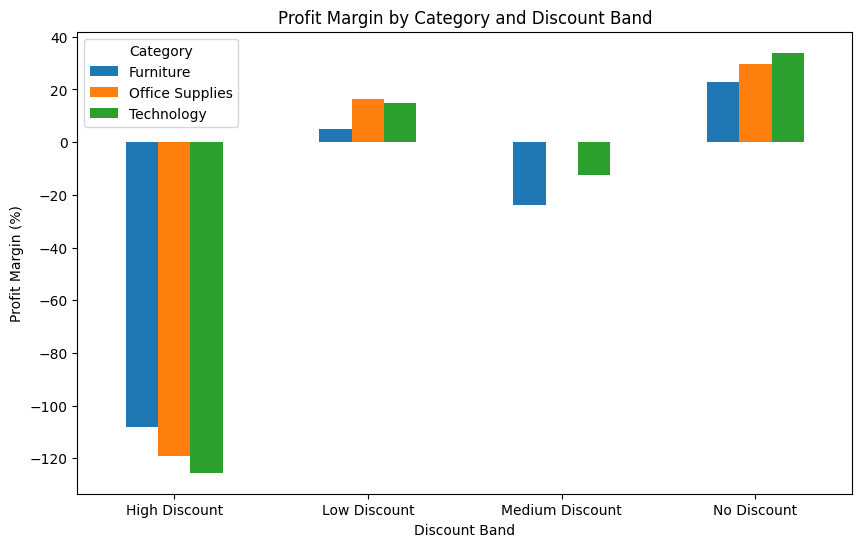

In [45]:
category_discount_pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Profit Margin by Category and Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()

The discount analysis by category shows that profitability changes significantly depending on the discount level and product category. This is especially important for Furniture because it already has the weakest profit margin among the main categories.

The business should review discount policies by category instead of using the same discounting strategy across all products.

### 10.9 Monthly Sales and Profit Trends

Next, I analyzed monthly sales and profit trends. This helps identify changes in business performance over time and shows whether sales growth is consistently leading to profit growth.

In [46]:
monthly_trend = run_query("""
SELECT
    order_month,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY order_month
ORDER BY order_month;
""")

monthly_trend.head(10)

,order_month,total_sales,total_profit,profit_margin_percent,total_orders
0,2014-01,"14,236.90","2,450.19",17.21,32
1,2014-02,"4,519.89",862.31,19.08,28
2,2014-03,"55,691.01",498.73,0.90,71
3,2014-04,"28,295.35","3,488.84",12.33,66
4,2014-05,"23,648.29","2,738.71",11.58,69
5,2014-06,"34,595.13","4,976.52",14.39,66
6,2014-07,"33,946.39",-841.48,-2.48,65
7,2014-08,"27,909.47","5,318.11",19.05,72
8,2014-09,"81,777.35","8,328.10",10.18,130
9,2014-10,"31,453.39","3,448.26",10.96,78


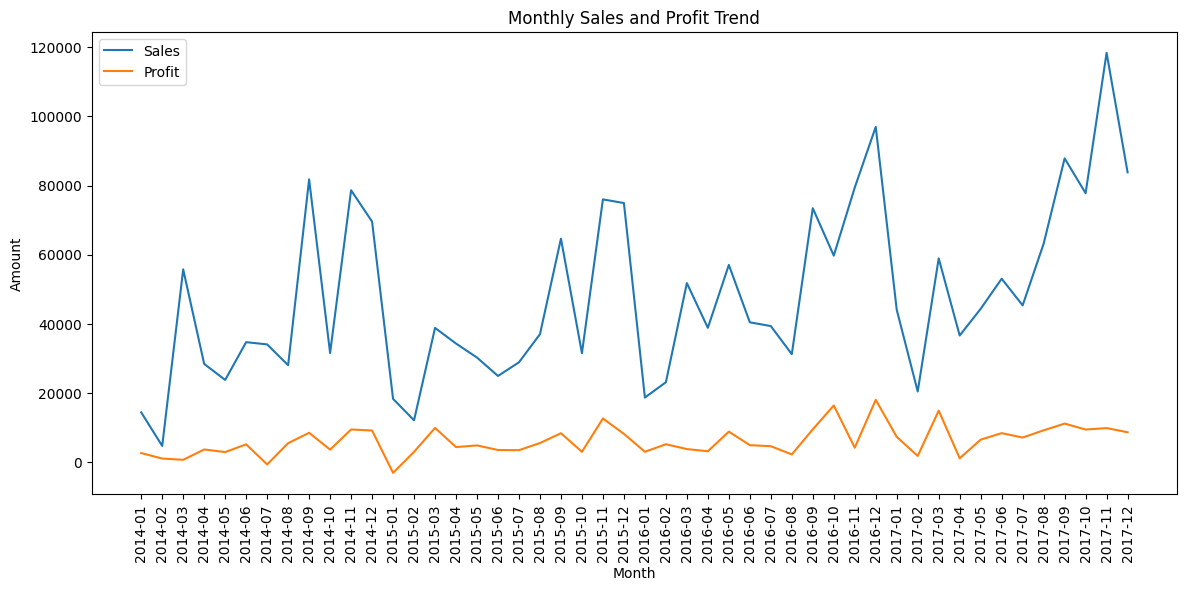

In [47]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_trend["order_month"], monthly_trend["total_sales"], label="Sales")
plt.plot(monthly_trend["order_month"], monthly_trend["total_profit"], label="Profit")
plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [48]:
yearly_trend = run_query("""
SELECT
    SUBSTR(order_date, 1, 4) AS order_year,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY SUBSTR(order_date, 1, 4)
ORDER BY order_year;
""")

yearly_trend

,order_year,total_sales,total_profit,profit_margin_percent,total_orders
0,2014,"484,247.50","49,543.97",10.23,969
1,2015,"470,532.51","61,618.60",13.10,1038
2,2016,"609,205.60","81,795.17",13.43,1315
3,2017,"733,215.26","93,439.27",12.74,1687


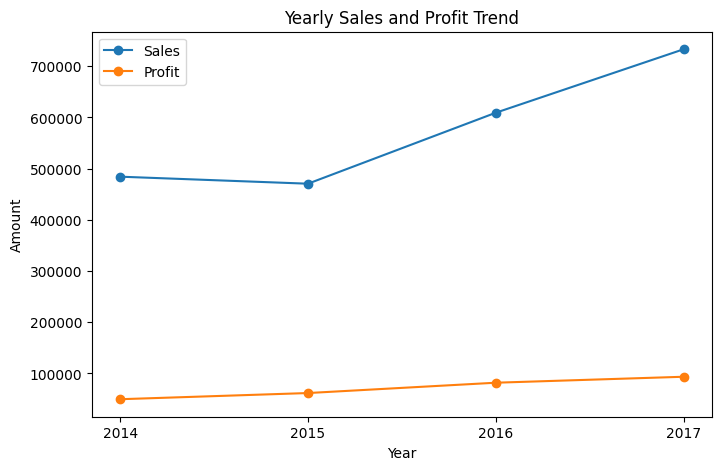

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(yearly_trend["order_year"], yearly_trend["total_sales"], marker="o", label="Sales")
plt.plot(yearly_trend["order_year"], yearly_trend["total_profit"], marker="o", label="Profit")
plt.title("Yearly Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.show()

Sales and profit changed over time, with some months showing stronger sales while profit did not always increase at the same rate. This supports the idea that sales volume should not be evaluated by itself. Profit margin is also important because it shows whether the business is earning enough profit from its sales.

### 10.10 Shipping Analysis

I also reviewed shipping mode and shipping days to understand whether delivery method is connected to sales, profit, or order volume. This analysis is secondary to the main profitability analysis, but it provides additional context about customer orders.

In [50]:
shipping_mode_performance = run_query("""
SELECT
    ship_mode,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(AVG(shipping_days), 2) AS avg_shipping_days,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent
FROM superstore
GROUP BY ship_mode
ORDER BY total_orders DESC;
""")

shipping_mode_performance

,ship_mode,total_orders,avg_shipping_days,total_sales,total_profit,profit_margin_percent
0,Standard Class,2994,5.01,"1,358,215.74","164,088.79",12.08
1,Second Class,964,3.24,"459,193.57","57,446.64",12.51
2,First Class,787,2.18,"351,428.42","48,969.84",13.93
3,Same Day,264,0.04,"128,363.13","15,891.76",12.38


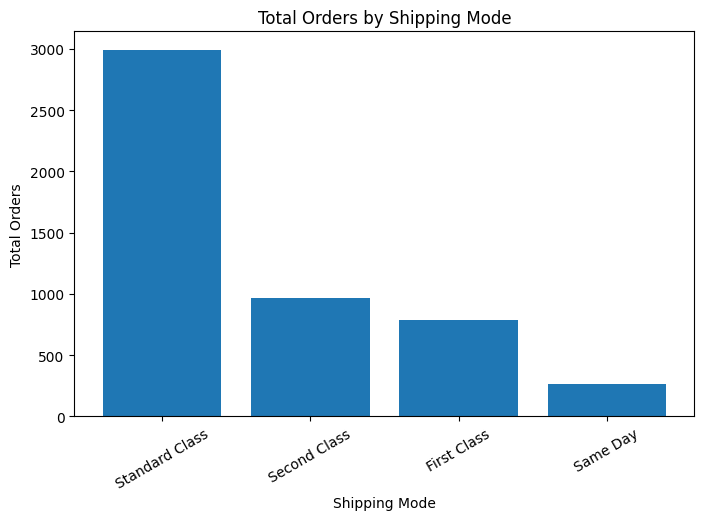

In [51]:
plt.figure(figsize=(8, 5))
plt.bar(shipping_mode_performance["ship_mode"], shipping_mode_performance["total_orders"])
plt.title("Total Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Orders")
plt.xticks(rotation=30)
plt.show()

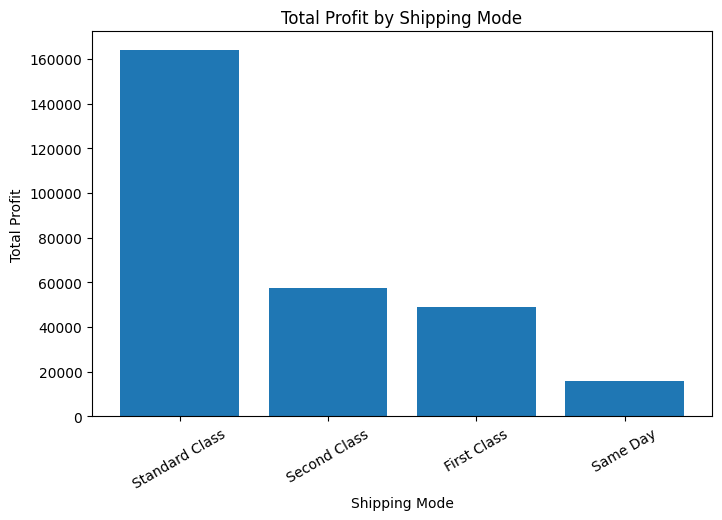

In [52]:
plt.figure(figsize=(8, 5))
plt.bar(shipping_mode_performance["ship_mode"], shipping_mode_performance["total_profit"])
plt.title("Total Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Profit")
plt.xticks(rotation=30)
plt.show()

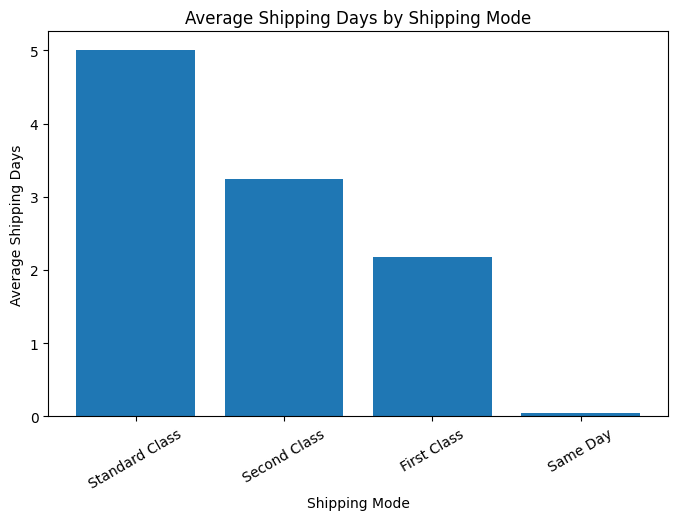

In [53]:
plt.figure(figsize=(8, 5))
plt.bar(shipping_mode_performance["ship_mode"], shipping_mode_performance["avg_shipping_days"])
plt.title("Average Shipping Days by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=30)
plt.show()

Standard Class had the highest number of orders, which makes it the most commonly used shipping mode in the dataset. Shipping mode provides useful context about order behavior, but the main business opportunities in this analysis are more strongly connected to product profitability and discounting.

### 10.11 Product-Level Analysis

After reviewing categories and sub-categories, I analyzed individual products. This helps identify specific products that generate strong sales, strong profit, or major losses.

This step is important because some products may have high sales but low or negative profit.

In [54]:
top_products_by_sales = run_query("""
SELECT
    product_name,
    category,
    sub_category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY product_name, category, sub_category
ORDER BY total_sales DESC
LIMIT 10;
""")

top_products_by_sales

,product_name,category,sub_category,total_sales,total_profit,profit_margin_percent,total_orders
0,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"61,599.82","25,199.93",40.91,5
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,"27,453.38","7,753.04",28.24,10
2,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,"22,638.48","-1,811.08",-8.00,1
3,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,"21,870.58",0.00,0.00,8
4,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,"19,823.48","2,233.51",11.27,11
5,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,"19,024.50",760.98,4.00,9
6,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,"18,839.69","6,983.88",37.07,8
7,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,"18,374.90","4,094.98",22.29,3
8,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,"17,965.07","-1,878.17",-10.45,6
9,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,"17,030.31",-262.00,-1.54,3


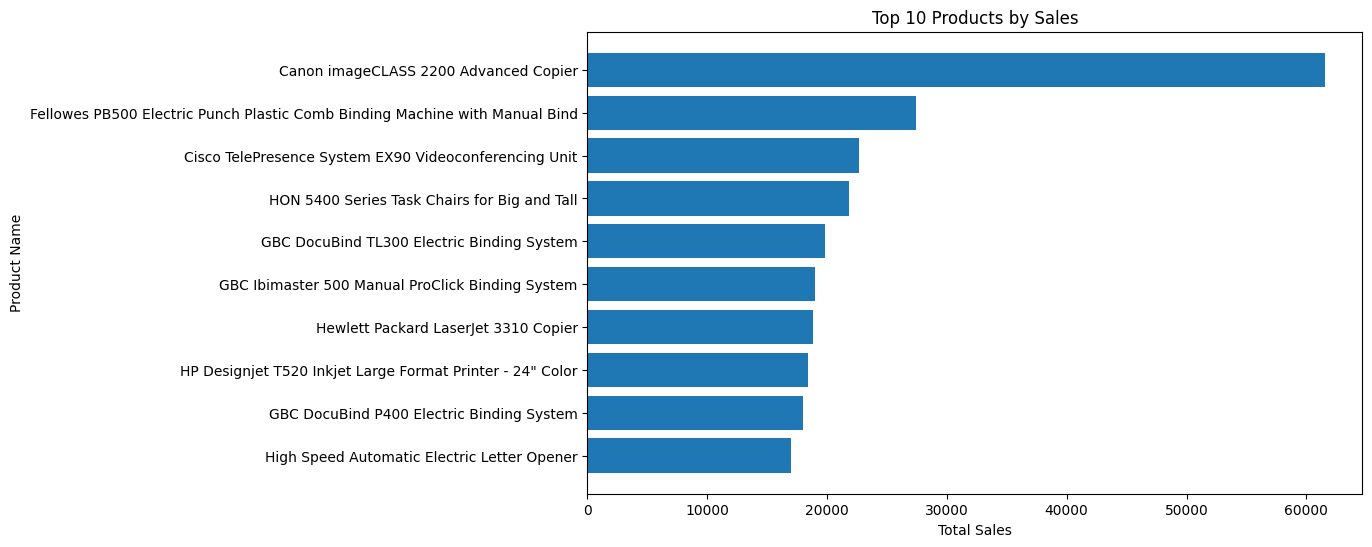

In [55]:
plt.figure(figsize=(10, 6))
plt.barh(top_products_by_sales["product_name"], top_products_by_sales["total_sales"])
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.show()

In [56]:
top_products_by_profit = run_query("""
SELECT
    product_name,
    category,
    sub_category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY product_name, category, sub_category
ORDER BY total_profit DESC
LIMIT 10;
""")

top_products_by_profit

,product_name,category,sub_category,total_sales,total_profit,profit_margin_percent,total_orders
0,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"61,599.82","25,199.93",40.91,5
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,"27,453.38","7,753.04",28.24,10
2,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,"18,839.69","6,983.88",37.07,8
3,Canon PC1060 Personal Laser Copier,Technology,Copiers,"11,619.83","4,570.93",39.34,4
4,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,"18,374.90","4,094.98",22.29,3
5,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,"7,699.89","3,772.95",49.00,2
6,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,"14,299.89","3,717.97",26.00,2
7,Plantronics Savi W720 Multi-Device Wireless He...,Technology,Accessories,"9,367.29","3,696.28",39.46,7
8,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,"15,875.92","3,345.28",21.07,3
9,Zebra ZM400 Thermal Label Printer,Technology,Machines,"6,965.70","3,343.54",48.00,2


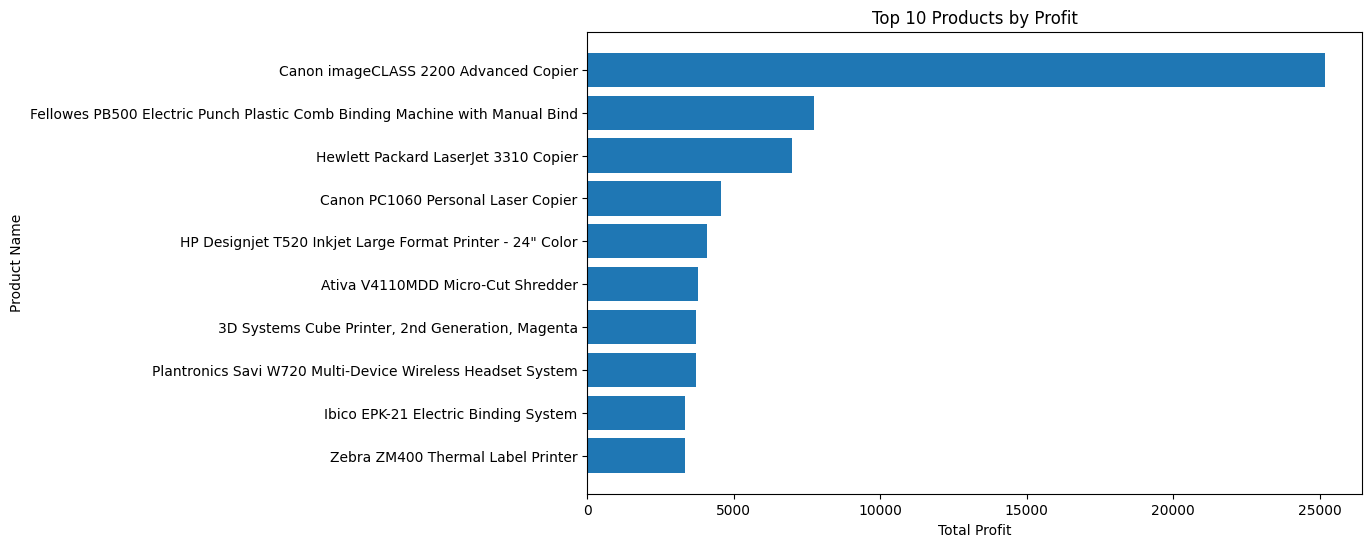

In [57]:
plt.figure(figsize=(10, 6))
plt.barh(top_products_by_profit["product_name"], top_products_by_profit["total_profit"])
plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.show()

In [58]:
bottom_products_by_profit = run_query("""
SELECT
    product_name,
    category,
    sub_category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY product_name, category, sub_category
ORDER BY total_profit ASC
LIMIT 10;
""")

bottom_products_by_profit

,product_name,category,sub_category,total_sales,total_profit,profit_margin_percent,total_orders
0,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,"11,099.96","-8,879.97",-80.00,3
1,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,"16,829.90","-4,589.97",-27.27,4
2,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,"7,999.98","-3,839.99",-48.00,1
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,"9,917.64","-2,876.12",-29.00,5
4,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,"9,544.73","-1,934.40",-20.27,7
5,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,"17,965.07","-1,878.17",-10.45,6
6,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,"22,638.48","-1,811.08",-8.00,1
7,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,"16,656.20","-1,299.18",-7.80,6
8,Balt Solid Wood Round Tables,Furniture,Tables,"6,518.75","-1,201.06",-18.42,4
9,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,"1,706.25","-1,148.44",-67.31,3


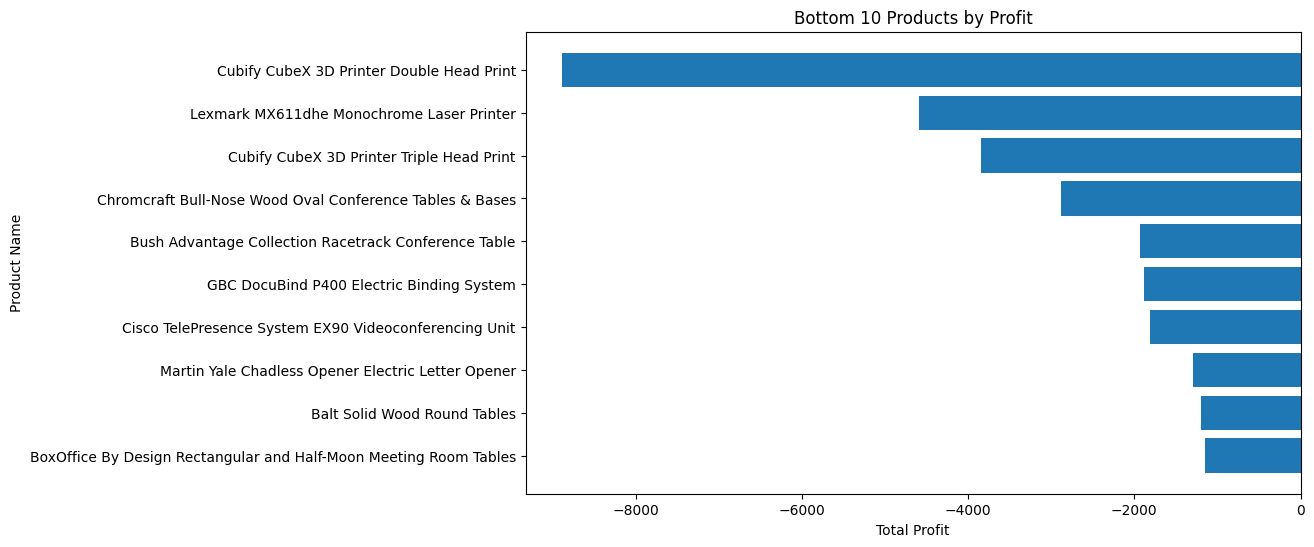

In [59]:
plt.figure(figsize=(10, 6))
plt.barh(bottom_products_by_profit["product_name"], bottom_products_by_profit["total_profit"])
plt.title("Bottom 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.show()

In [60]:
high_sales_negative_profit = run_query("""
SELECT
    product_name,
    category,
    sub_category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percent,
    COUNT(DISTINCT order_id) AS total_orders
FROM superstore
GROUP BY product_name, category, sub_category
HAVING SUM(sales) > 10000
   AND SUM(profit) < 0
ORDER BY total_sales DESC;
""")

high_sales_negative_profit

,product_name,category,sub_category,total_sales,total_profit,profit_margin_percent,total_orders
0,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,"22,638.48","-1,811.08",-8.00,1
1,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,"17,965.07","-1,878.17",-10.45,6
2,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,"17,030.31",-262.00,-1.54,3
3,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,"16,829.90","-4,589.97",-27.27,4
4,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,"16,656.20","-1,299.18",-7.80,6
5,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,"15,610.97",-669.54,-4.29,5
6,Bretford Rectangular Conference Table Tops,Furniture,Tables,"12,995.29",-327.23,-2.52,12
7,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,"11,099.96","-8,879.97",-80.00,3


The product-level analysis shows why it is important to compare both sales and profit. Some products generated high sales but still produced losses. These products should be reviewed because they may be affected by high discounts, weak margins, high costs, or pricing issues.

The business should not judge product success by sales alone. A product should be evaluated by sales, profit, and profit margin together.

### 10.12 Product-Level Findings

The product-level analysis showed that the Canon imageCLASS 2200 Advanced Copier was both the highest-sales product and the highest-profit product. It generated approximately $61.6K in sales and $25.2K in profit.

However, some high-sales products produced negative profit. For example, the Cisco TelePresence System EX90 Videoconferencing Unit generated approximately $22.6K in sales but lost about $1.8K. The GBC DocuBind P400 Electric Binding System also generated nearly $18.0K in sales but lost about $1.9K.

The weakest product by profit was the Cubify CubeX 3D Printer Double Head Print, which lost about $8.9K. Several of the worst-performing products came from the Machines and Tables sub-categories.

This confirms that the business should evaluate products by sales, profit, and profit margin together instead of relying on sales alone.

## 11. Tableau Dashboard

I created an interactive Tableau dashboard to present the main findings from this analysis. The dashboard includes KPI cards, regional performance, state-level sales and profit, product category analysis, sub-category profitability, customer segment performance, monthly trends, and discount impact.

The cleaned dataset was exported from this notebook and used in Tableau Public.

In [61]:
# Export cleaned data for Tableau
df.to_csv("superstore_cleaned_for_tableau.csv", index=False)

print("Cleaned Tableau file created: superstore_cleaned_for_tableau.csv")

Cleaned Tableau file created: superstore_cleaned_for_tableau.csv


[View the Tableau Dashboard](https://public.tableau.com/app/profile/aaron.navarro2958/viz/SuperstoreSalesandProfitabilityDashboard_17795624443720/SuperstoreSalesProfitabilityDashboard#1)

## 12. Key Findings

The analysis found several important patterns in the Superstore data:

1. The business generated approximately $2.30M in sales and $286.4K in profit.
2. The overall profit margin was 12.47%.
3. Sales and profit both increased from 2014 to 2017.
4. The West region generated the highest total profit.
5. The Central region had the weakest profit margin.
6. Technology was the most profitable category.
7. Furniture had weak profitability despite high sales.
8. Tables, Bookcases, and Supplies were unprofitable sub-categories.
9. Consumer customers generated the most total sales and profit.
10. Discounts above 20% were associated with negative profitability.
11. Some individual products had high sales but negative profit.

## 13. Recommendations

Based on the analysis, the business should focus on improving profitability instead of only increasing sales volume.

First, the company should review discounts above 20% because medium and high discount bands were associated with negative profit margins. Discounting may help increase sales, but the data shows that aggressive discounts can reduce or eliminate profit.

Second, the company should investigate Furniture profitability, especially Tables and Bookcases. Furniture generated a large amount of sales, but it had the weakest profit margin among the main categories.

Third, the business should promote stronger profit areas such as Technology and Office Supplies. Sub-categories such as Copiers, Paper, Accessories, and Phones generated strong profit and should be considered for future sales and marketing strategies.

Fourth, the company should review regional differences. The West and East regions generated the highest profits, while the Central region had the weakest profit margin. Understanding these differences could help improve pricing, product mix, and discount strategy by region.

Finally, the business should review high-sales products that produce negative profit. These products may need pricing changes, discount limits, or cost review before being promoted further.

## 14. Conclusion

This analysis shows that the Superstore business is profitable overall, but profitability varies significantly by region, category, sub-category, discount level, and product.

The strongest profit drivers were the West region, the Technology category, and high-performing sub-categories such as Copiers, Paper, Accessories, and Phones. The weakest areas were Furniture, especially Tables and Bookcases, along with high-discount orders.

The biggest business issue found in the analysis was discounting. Orders with no discount had a profit margin of 29.51%, while medium and high discount bands had negative profit margins. This suggests that aggressive discounting may be reducing overall profitability.

To improve performance, the business should reduce unnecessary high discounts, review low-profit Furniture products, promote high-margin categories, and evaluate products based on profit instead of sales volume alone.